# 문항 유형 수에 따른 분류 성능 변화 (박스플롯) — RQ2: 일반화

## 목적
학습에 사용하는 문항 유형(인지적 과제 유형) 수가 변할 때 분류 성능(Kappa)이 어떻게 달라지는지 비교합니다. "더 다양한 유형으로 학습하면 일반화가 향상되는가?"라는 질문에 답합니다.

## 주요 용어
- **박스플롯(Box Plot)**: 데이터의 중앙값, 사분위수, 이상값을 한눈에 보여주는 차트. 상자의 가운데 선이 중앙값, 상자의 상하단이 25%/75% 지점, 수염이 데이터 범위를 나타냄
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함

## 문항 유형 (4종류)
| 유형 | 해당 문항 | 설명 |
|:---:|:---:|:---|
| 자료해석/결론 | Q1, Q3 | 실험 데이터를 해석하고 결론 도출 |
| 실험설계 | Q2, Q6 | 실험 방법과 변인 통제 설계 |
| 예측 | Q4, Q5 | 결과 예측 및 근거 제시 |
| 가설평가 | Q7, Q8 | 가설의 타당성 평가 |

## 시각화 구성
- A) 학습 유형 수(1, 2, 3)에 따른 통합 박스플롯
- B) 학습 유형 수 x 유형당 문항 수(6개 조건) 비교
- C) 유형당 문항 수별 서브플롯으로 분리
- D) 접근법별 개별 박스플롯 + 평균 추세선

In [11]:
# ============================================================
# 라이브러리 및 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

# --- 한글 폰트 설정 ---
# macOS: AppleGothic / Windows: 'Malgun Gothic' / Linux: 'NanumGothic'
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

print('라이브러리 및 한글 폰트 설정 완료')

라이브러리 및 한글 폰트 설정 완료


In [ ]:
# ============================================================
# 데이터 파일 경로 설정
# - 노트북 위치: Git/5_result/
# - 파일 경로를 수정하려면 이 셀만 변경하세요
# ============================================================

# 유형 조합별 ML(24모델 평균/최고) + BERT Kappa 결과
# 컬럼: n_train_types, n_test_types, q_per_type, train_types, test_types,
#        train_qs, test_qs, combo, ML_Mean_Kappa, ML_Max_Kappa, ML_Best_Model,
#        BERT_Kappa, N_test
TYPE_COMBO_PATH = '../4_llm/results/full_evaluation/type_combo/type_combo_all_results.csv'

# LLM 예측 결과 (GPT-4o, 전체 데이터셋 예측)
# 컬럼: id, y_true, Q, q_type, pred_run1, all_same, majority_pred
LLM_PRED_PATH = '../4_llm/results/full_evaluation/llm_wide_predictions.csv'

print('파일 경로 설정 완료')

In [13]:
# ============================================================
# 데이터 로드
# ============================================================

# --- ML + BERT 유형 조합 결과 ---
# 각 행 = 특정 유형 조합(학습 유형 → 테스트 유형, 유형당 문항 수)
# ML_Mean_Kappa: 24개 모델(앙상블 포함) 평균 Kappa
# BERT_Kappa: KLUE-BERT 단일 모델 Kappa
type_combo = pd.read_csv(TYPE_COMBO_PATH)
print(f'유형 조합 데이터: {len(type_combo)}행')
print(f'  n_train_types 범위: {sorted(type_combo["n_train_types"].unique())}')
print(f'  q_per_type 범위: {sorted(type_combo["q_per_type"].unique())}')

# --- LLM 예측 결과 ---
llm_pred = pd.read_csv(LLM_PRED_PATH)
llm_pred['y_true'] = llm_pred['y_true'].astype(int)
llm_pred['majority_pred'] = llm_pred['majority_pred'].astype(int)
print(f'\nLLM 예측 데이터: {len(llm_pred)}행')
print(f'  문항별 분포: {llm_pred["Q"].value_counts().sort_index().to_dict()}')

유형 조합 데이터: 210행
  n_train_types 범위: [1, 2, 3]
  q_per_type 범위: [1, 2]

LLM 예측 데이터: 2080행
  문항별 분포: {'Q1': 265, 'Q2': 265, 'Q3': 265, 'Q4': 265, 'Q5': 255, 'Q6': 255, 'Q7': 255, 'Q8': 255}


In [14]:
# ============================================================
# LLM Kappa 계산 (각 유형 조합의 테스트 문항에 대해)
# - LLM은 프롬프트 기반이므로 학습 과정이 없음
# - 각 조합의 test_qs에 해당하는 문항만 필터링하여 Kappa 계산
# - 이를 통해 ML/BERT와 동일한 테스트셋에서의 성능을 비교
# ============================================================

def compute_llm_kappa(test_qs_str):
    """test_qs 문자열(예: 'Q2,Q6')을 파싱하여 해당 문항의 LLM Kappa 계산."""
    test_qs = [q.strip() for q in str(test_qs_str).split(',')]
    subset = llm_pred[llm_pred['Q'].isin(test_qs)]
    if len(subset) < 2:
        return np.nan
    return cohen_kappa_score(subset['y_true'], subset['majority_pred'])

type_combo['LLM_Kappa'] = type_combo['test_qs'].apply(compute_llm_kappa)

# 검증: LLM Kappa 계산 결과 확인
print('LLM Kappa 계산 완료')
print(f'  유효한 값: {type_combo["LLM_Kappa"].notna().sum()}/{len(type_combo)}')
print(f'  범위: {type_combo["LLM_Kappa"].min():.4f} ~ {type_combo["LLM_Kappa"].max():.4f}')

LLM Kappa 계산 완료
  유효한 값: 210/210
  범위: 0.5656 ~ 0.6542


In [15]:
# ============================================================
# 박스플롯용 long-format 데이터 구성
# - 각 행 = (조합, 접근법, Kappa, 그룹 변수들)
# - ML: ML_Mean_Kappa (24개 모델 평균, 앙상블 포함)
# - BERT: BERT_Kappa (KLUE-BERT)
# - LLM: LLM_Kappa (GPT-4o 예측 기반 계산)
# ============================================================

records = []
for _, row in type_combo.iterrows():
    base = {
        'n_train_types': int(row['n_train_types']),
        'q_per_type': int(row['q_per_type']),
        'combo': row['combo'],
    }
    records.append({**base, 'Approach': 'ML', 'Kappa': row['ML_Mean_Kappa']})
    records.append({**base, 'Approach': 'BERT', 'Kappa': row['BERT_Kappa']})
    records.append({**base, 'Approach': 'LLM', 'Kappa': row['LLM_Kappa']})

df_long = pd.DataFrame(records)

# 접근법 순서 지정 (그래프에서 ML → BERT → LLM 순서로 표시)
df_long['Approach'] = pd.Categorical(
    df_long['Approach'], categories=['ML', 'BERT', 'LLM'], ordered=True
)

print('Long-format 데이터 구성 완료')
print(f'  전체 행: {len(df_long)}')
print(f'\n그룹별 데이터 포인트 수:')
print(df_long.groupby(['n_train_types', 'Approach']).size().unstack(fill_value=0))

Long-format 데이터 구성 완료
  전체 행: 630

그룹별 데이터 포인트 수:
Approach       ML  BERT  LLM
n_train_types               
1              84    84   84
2              90    90   90
3              36    36   36


In [ ]:
# ============================================================
# 공통 시각화 설정
# - 색상, 범례, 기준선 등 3개 그래프에서 공통으로 사용
# - 색상/스타일 변경은 이 셀에서만 수정하면 됩니다
# ============================================================

# 색상 팔레트 (04_5050_comparison.ipynb과 동일)
PALETTE = {
    'ML':   '#4A90D9',   # 파란색 계열
    'BERT': '#E8834A',   # 주황색 계열
    'LLM':  '#67B279'    # 초록색 계열
}

# 박스플롯 스타일
BOX_KW = dict(
    width=0.6,
    fliersize=3,
    linewidth=0.8,
)

# 개별 데이터 포인트 스타일 (stripplot)
STRIP_KW = dict(
    size=3,
    alpha=0.35,
    jitter=True,
    legend=False,
)

def add_kappa_guidelines(ax, ymin=0.3, show_labels=True):
    """Kappa 해석 기준선 추가 (Landis & Koch, 1977).
    
    서브플롯 사용 시: 마지막 패널에만 show_labels=True,
    나머지는 show_labels=False로 호출하면 라벨 중복 방지.
    """
    guidelines = [
        (0.4, 'Moderate'),
        (0.6, 'Substantial'),
        (0.8, 'Almost Perfect'),
    ]
    for y, label in guidelines:
        if y >= ymin:
            ax.axhline(y=y, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
            if show_labels:
                ax.annotate(
                    label,
                    xy=(1.0, y),
                    xycoords=('axes fraction', 'data'),
                    xytext=(6, 0),
                    textcoords='offset points',
                    fontsize=7, color='gray', alpha=0.7,
                    va='center', ha='left',
                    annotation_clip=False,
                )

print('공통 시각화 설정 완료')

## A) 학습 유형 수(n_train_types)에 따른 변화

- x축: 학습에 사용한 문항 유형 수 (1, 2, 3)
- 유형당 문항 수(1문항/2문항)는 모두 포함하여 통합
- 각 접근법별 박스플롯으로 분포 비교

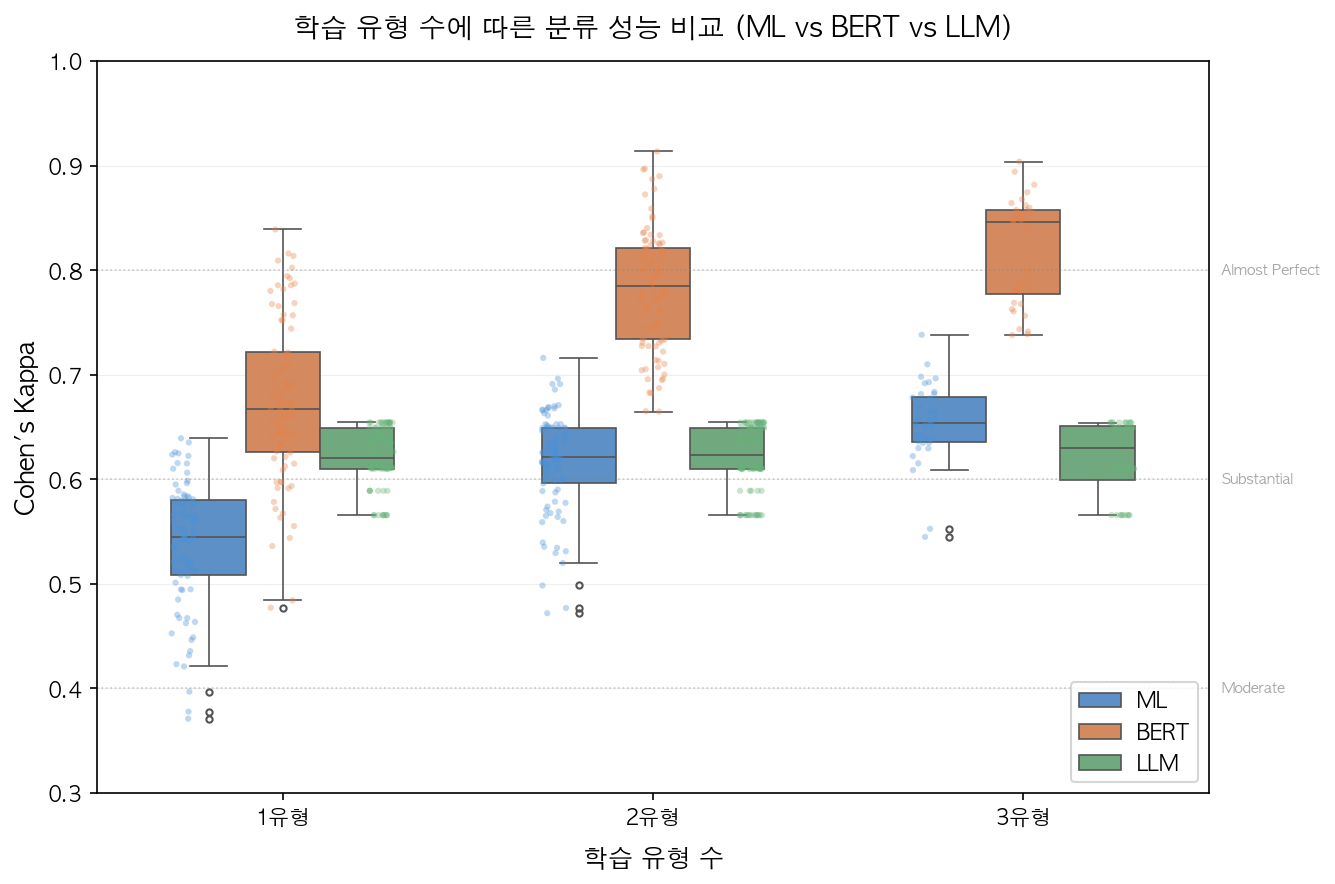


=== 그룹별 Kappa 요약 통계 ===
                          mean     std     min     max  count
n_train_types Approach                                       
1             ML        0.5364  0.0605  0.3708  0.6391   84.0
              BERT      0.6742  0.0779  0.4770  0.8388   84.0
              LLM       0.6218  0.0280  0.5656  0.6542   84.0
2             ML        0.6163  0.0477  0.4718  0.7160   90.0
              BERT      0.7823  0.0576  0.6646  0.9135   90.0
              LLM       0.6209  0.0319  0.5656  0.6542   90.0
3             ML        0.6532  0.0381  0.5447  0.7381   36.0
              BERT      0.8192  0.0503  0.7379  0.9037   36.0
              LLM       0.6198  0.0362  0.5656  0.6542   36.0


In [21]:
# ============================================================
# A) 학습 유형 수에 따른 박스플롯
# - x축: 학습 유형 수 (1, 2, 3)
# - 유형당 문항 수(q_per_type) 통합
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# 박스플롯
sns.boxplot(
    data=df_long, x='n_train_types', y='Kappa', hue='Approach',
    palette=PALETTE, ax=ax, **BOX_KW
)

# 개별 데이터 포인트 표시 (분포 확인용)
sns.stripplot(
    data=df_long, x='n_train_types', y='Kappa', hue='Approach',
    palette=PALETTE, dodge=True, ax=ax, **STRIP_KW
)

# 축 설정
ax.set_xlabel('학습 유형 수', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax.set_title('학습 유형 수에 따른 분류 성능 비교 (ML vs BERT vs LLM)',
             fontsize=13, fontweight='bold', pad=12)

# x축 라벨
n_counts = df_long.groupby('n_train_types')['combo'].nunique() // 1  # 접근법 무관
type_counts = type_combo.groupby('n_train_types').size()
ax.set_xticklabels([
    f'{t}유형'
    for t in sorted(df_long['n_train_types'].unique())
], fontsize=10)

# 범례 정리 (stripplot 중복 제거)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], fontsize=10, loc='lower right')

# y축 범위 및 기준선
ax.set_ylim(0.3, 1.0)
add_kappa_guidelines(ax, ymin=0.3)

ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('type_boxplot_A_by_ntypes.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 요약 통계
print('\n=== 그룹별 Kappa 요약 통계 ===')
summary_a = df_long.groupby(['n_train_types', 'Approach'])['Kappa'].describe()[['mean', 'std', 'min', 'max', 'count']]
print(summary_a.round(4).to_string())

**결과 해석:**

학습 유형 수(1, 2, 3)에 따른 박스플롯입니다.

- **ML**: 유형 수가 증가할수록 중앙값과 평균이 소폭 상승하며 분산이 감소 → 다양한 유형으로 학습하면 안정성이 향상
- **BERT**: 1유형에서도 이미 높은 성능(~0.65)을 보이며, 유형 수 증가에 따른 향상이 ML보다 큼 → 사전학습 언어모델의 전이 학습 효과
- **LLM**: 학습 과정이 없으므로 유형 수와 무관하게 일정한 Kappa(~0.62) → 프롬프트 기반 분류의 안정성을 보여주지만, 학습 기반 모델의 상한에 미치지 못함
- **시사점**: BERT는 소수의 유형(1-2개)으로도 준수한 성능을 달성하여, 실제 교육 현장에서의 데이터 수집 부담을 줄일 수 있음

## B) 학습 유형 수 × 유형당 문항 수 (6개 조건)

- x축: (유형 수, 유형당 문항 수) 조합 — 총 6개
- 유형당 1문항과 2문항의 효과를 동시에 비교

**결과 해석:**

6개 조건(유형 수 x 유형당 문항 수) 박스플롯입니다. 점선으로 구분된 영역은 유형 수 그룹(1유형, 2유형, 3유형)을 나타냅니다.

- **유형당 2문항 vs 1문항**: 동일 유형 수에서 유형당 2문항(예: Q1+Q3)으로 학습하면 1문항보다 성능이 향상됨 → 같은 유형의 다양한 문항이 학습에 도움
- **3유형x2문항(6문항)**: 가장 높은 성능 → 유형 다양성과 문항 수가 동시에 충족될 때 최적 성능
- **LLM**: 모든 조건에서 일정한 Kappa → 학습 조건 변화에 영향받지 않는 특성 확인

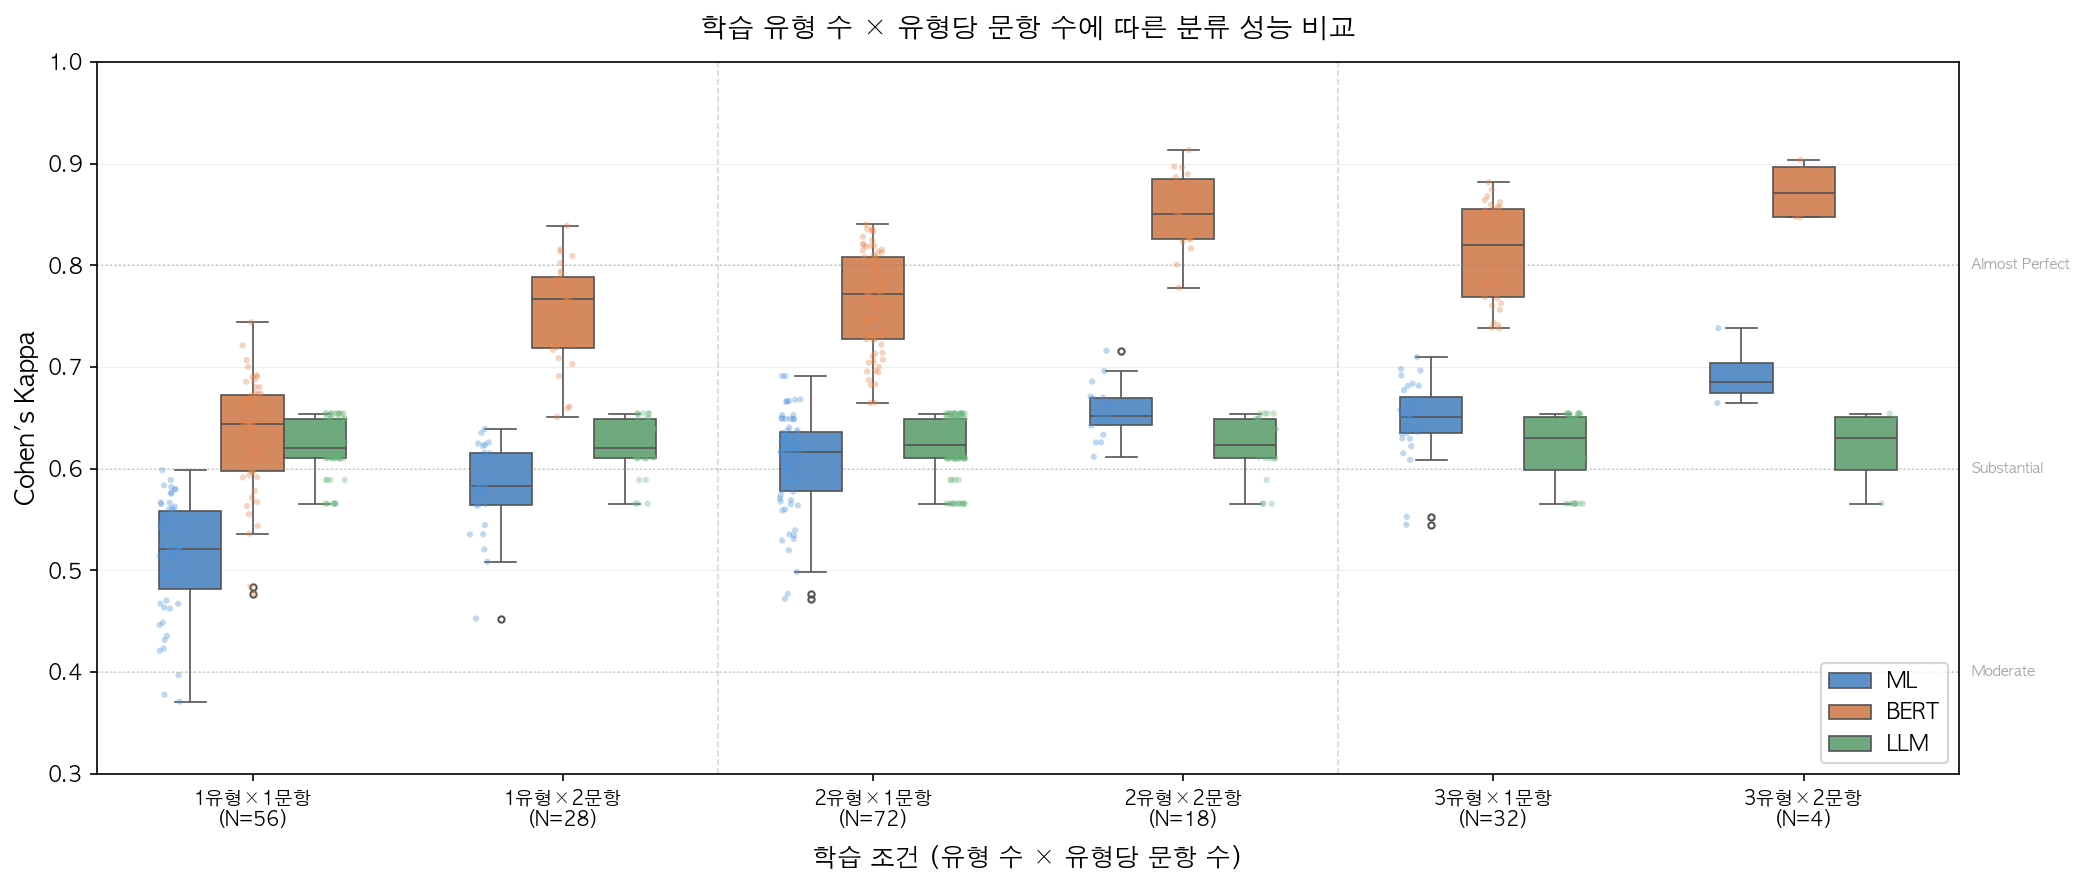


=== 조건별 Kappa 요약 통계 ===
                      mean     std  count
condition Approach                       
1유형×1문항   ML        0.5142  0.0557   56.0
          BERT      0.6339  0.0542   56.0
          LLM       0.6218  0.0280   56.0
1유형×2문항   ML        0.5809  0.0429   28.0
          BERT      0.7549  0.0504   28.0
          LLM       0.6218  0.0283   28.0
2유형×1문항   ML        0.6061  0.0466   72.0
          BERT      0.7651  0.0482   72.0
          LLM       0.6209  0.0320   72.0
2유형×2문항   ML        0.6567  0.0259   18.0
          BERT      0.8511  0.0377   18.0
          LLM       0.6209  0.0326   18.0
3유형×1문항   ML        0.6481  0.0361   32.0
          BERT      0.8125  0.0484   32.0
          LLM       0.6198  0.0362   32.0
3유형×2문항   ML        0.6933  0.0320    4.0
          BERT      0.8732  0.0300    4.0
          LLM       0.6198  0.0412    4.0


In [18]:
# ============================================================
# B) 학습 유형 수 × 유형당 문항 수 박스플롯
# - x축: '1유형×1문항', '1유형×2문항', ..., '3유형×2문항'
# - 6개 조건 × 3개 접근법 비교
# ============================================================

# x축 라벨 생성
df_long['condition'] = (
    df_long['n_train_types'].astype(str) + '유형×'
    + df_long['q_per_type'].astype(str) + '문항'
)

# 정렬 순서 지정 (유형 수 → 문항 수 순)
condition_order = [
    '1유형×1문항', '1유형×2문항',
    '2유형×1문항', '2유형×2문항',
    '3유형×1문항', '3유형×2문항',
]

# 조건별 데이터 포인트 수 계산
cond_counts = type_combo.assign(
    condition=type_combo['n_train_types'].astype(str) + '유형×'
    + type_combo['q_per_type'].astype(str) + '문항'
).groupby('condition').size()

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_long, x='condition', y='Kappa', hue='Approach',
    order=condition_order, palette=PALETTE, ax=ax, **BOX_KW
)

sns.stripplot(
    data=df_long, x='condition', y='Kappa', hue='Approach',
    order=condition_order, palette=PALETTE, dodge=True, ax=ax, **STRIP_KW
)

# 축 설정
ax.set_xlabel('학습 조건 (유형 수 × 유형당 문항 수)', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax.set_title('학습 유형 수 × 유형당 문항 수에 따른 분류 성능 비교',
             fontsize=13, fontweight='bold', pad=12)

# x축 라벨에 데이터 포인트 수 표시
ax.set_xticklabels([
    f'{c}\n(N={cond_counts.get(c, 0)})'
    for c in condition_order
], fontsize=9)

# 유형 수 구분선 (시각적 그룹핑)
for x_pos in [1.5, 3.5]:
    ax.axvline(x=x_pos, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

# 범례
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], fontsize=10, loc='lower right')

# y축 범위 및 기준선
ax.set_ylim(0.3, 1.0)
add_kappa_guidelines(ax, ymin=0.3)

ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('type_boxplot_B_by_condition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 요약 통계
print('\n=== 조건별 Kappa 요약 통계 ===')
summary_b = df_long.groupby(['condition', 'Approach'])['Kappa'].describe()[['mean', 'std', 'count']]
print(summary_b.round(4).to_string())

## C) 유형당 문항 수별 서브플롯

- 왼쪽: 유형당 1문항으로 학습
- 오른쪽: 유형당 2문항으로 학습
- 각 패널에서 학습 유형 수(1, 2, 3)에 따른 변화 비교

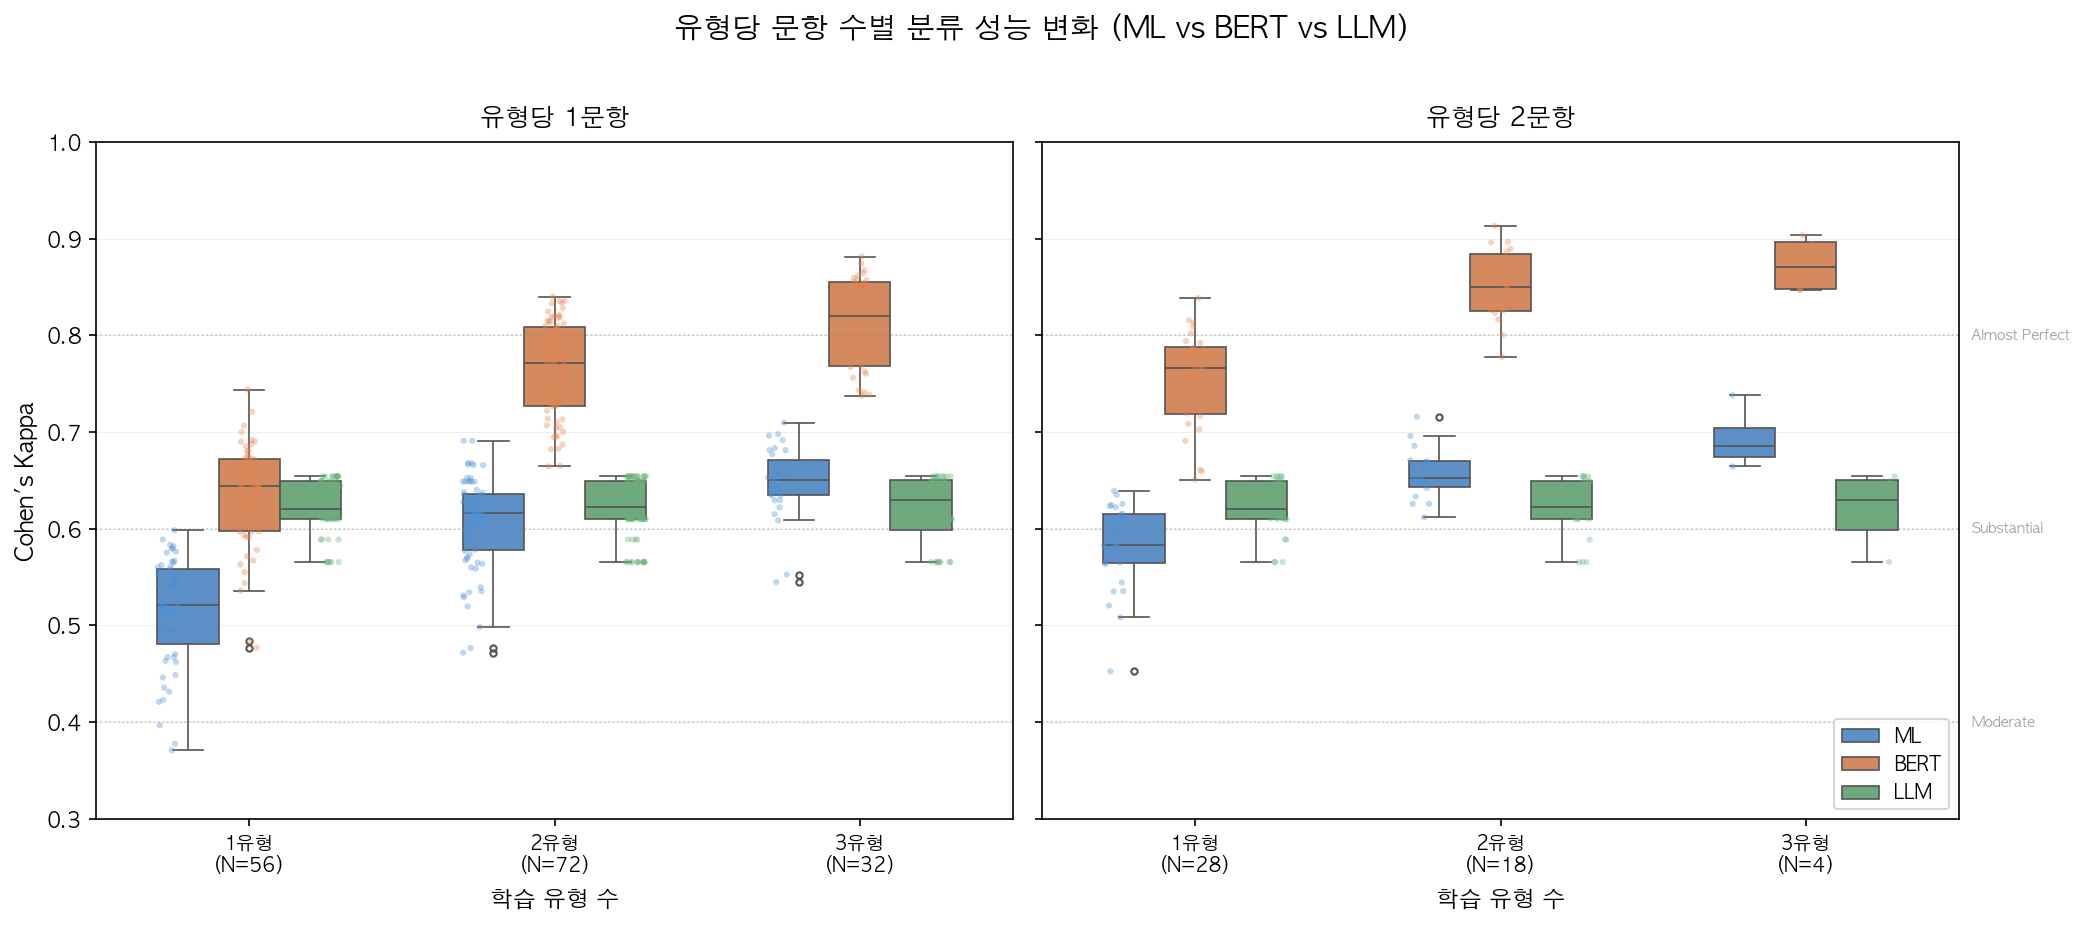


=== 유형당 문항 수 × 유형 수별 Kappa 평균 ===
Approach                      ML    BERT     LLM
q_per_type n_train_types                        
1          1              0.5142  0.6339  0.6218
           2              0.6061  0.7651  0.6209
           3              0.6481  0.8125  0.6198
2          1              0.5809  0.7549  0.6218
           2              0.6567  0.8511  0.6209
           3              0.6933  0.8732  0.6198


In [19]:
# ============================================================
# C) 유형당 문항 수별 서브플롯
# - 왼쪽: q_per_type=1 (유형당 1문항)
# - 오른쪽: q_per_type=2 (유형당 2문항)
# - 각 패널 내 x축: n_train_types (1, 2, 3)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for idx, (qpt, ax) in enumerate(zip([1, 2], axes)):
    subset = df_long[df_long['q_per_type'] == qpt]
    
    # 조건별 데이터 포인트 수
    sub_counts = type_combo[type_combo['q_per_type'] == qpt].groupby('n_train_types').size()
    
    sns.boxplot(
        data=subset, x='n_train_types', y='Kappa', hue='Approach',
        palette=PALETTE, ax=ax, **BOX_KW
    )
    
    sns.stripplot(
        data=subset, x='n_train_types', y='Kappa', hue='Approach',
        palette=PALETTE, dodge=True, ax=ax, **STRIP_KW
    )
    
    # 패널 제목
    ax.set_title(f'유형당 {qpt}문항', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('학습 유형 수', fontsize=11, fontweight='bold', labelpad=6)
    
    # x축 라벨에 N 표시
    ax.set_xticklabels([
        f'{t}유형\n(N={sub_counts.get(t, 0)})'
        for t in sorted(subset['n_train_types'].unique())
    ], fontsize=9)
    
    # y축 (왼쪽 패널만 라벨 표시)
    if idx == 0:
        ax.set_ylabel("Cohen's Kappa", fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel('')
    
    # 범례 (오른쪽 패널에만)
    handles, labels = ax.get_legend_handles_labels()
    if idx == 1:
        ax.legend(handles[:3], labels[:3], fontsize=9, loc='lower right')
    else:
        ax.get_legend().remove()
    
    # y축 범위 및 기준선 (라벨은 마지막 패널에만)
    ax.set_ylim(0.3, 1.0)
    add_kappa_guidelines(ax, ymin=0.3, show_labels=(idx == 1))
    
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

fig.suptitle('유형당 문항 수별 분류 성능 변화 (ML vs BERT vs LLM)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('type_boxplot_C_by_qpertype.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 요약 통계
print('\n=== 유형당 문항 수 × 유형 수별 Kappa 평균 ===')
summary_c = df_long.pivot_table(
    values='Kappa', index=['q_per_type', 'n_train_types'],
    columns='Approach', aggfunc='mean'
)
print(summary_c.round(4).to_string())

**결과 해석:**

접근법별 개별 박스플롯 + 평균 추세선(검은 점선)입니다.

- **ML 패널**: 유형 수 1->2->3으로 갈수록 평균 Kappa가 점진적으로 상승하며 분산이 줄어듦. 추세선의 기울기가 양(+)으로, 유형 다양성의 효과를 명확히 확인
- **BERT 패널**: ML과 유사한 상승 추세이지만 전체적으로 더 높은 수준. 1유형에서도 0.6 이상의 준수한 성능
- **LLM 패널**: 고유 Kappa 값 수가 적어 박스플롯이 좁음. 평균 ~0.62로, 테스트 문항 구성에만 약간의 변동이 있고 학습 유형 수와는 무관
- **ML vs LLM 교차점**: ML이 2유형 이상으로 학습하면 LLM 기준선을 초과 → 최소 2가지 유형의 학습 데이터가 있으면 ML이 LLM보다 유리

## D) 접근법별 개별 박스플롯 + 평균 추세선

- **왼쪽부터** ML → BERT → LLM 순서로 배치
- ML, BERT: 박스플롯 + 평균 Kappa 연결 추세선 (검은 점선)
- LLM: 아래 검토 결과 참고

### LLM 박스플롯 검토

LLM(GPT-4o)은 **프롬프트 기반 제로샷 분류**이므로 학습 과정이 없습니다.
따라서 "학습 유형 수"가 LLM 성능에 직접적인 영향을 미치지 않습니다.

각 n_train_types별 LLM 데이터 분석:
| 학습 유형 수 | 전체 조합 | 고유 Kappa 값 | 평균 Kappa |
|:---:|:---:|:---:|:---:|
| 1 | 84 | 14 | 0.622 |
| 2 | 90 | 10 | 0.621 |
| 3 | 36 | 4 | 0.620 |

**결론:**
- LLM Kappa는 **테스트 문항 구성에만** 의존하며, 학습 유형 수와 무관
- 동일한 test_qs를 공유하는 조합들은 **동일한 LLM Kappa**를 가짐 → 중복값 다수
- 평균 Kappa가 ~0.62로 거의 일정 → 추세선 무의미
- **박스플롯 표시는 가능하나**, 변동은 테스트셋 구성 차이를 반영할 뿐 학습 효과가 아님
- 따라서 LLM 패널에는 박스플롯 + **전체 평균 기준선**을 표시합니다

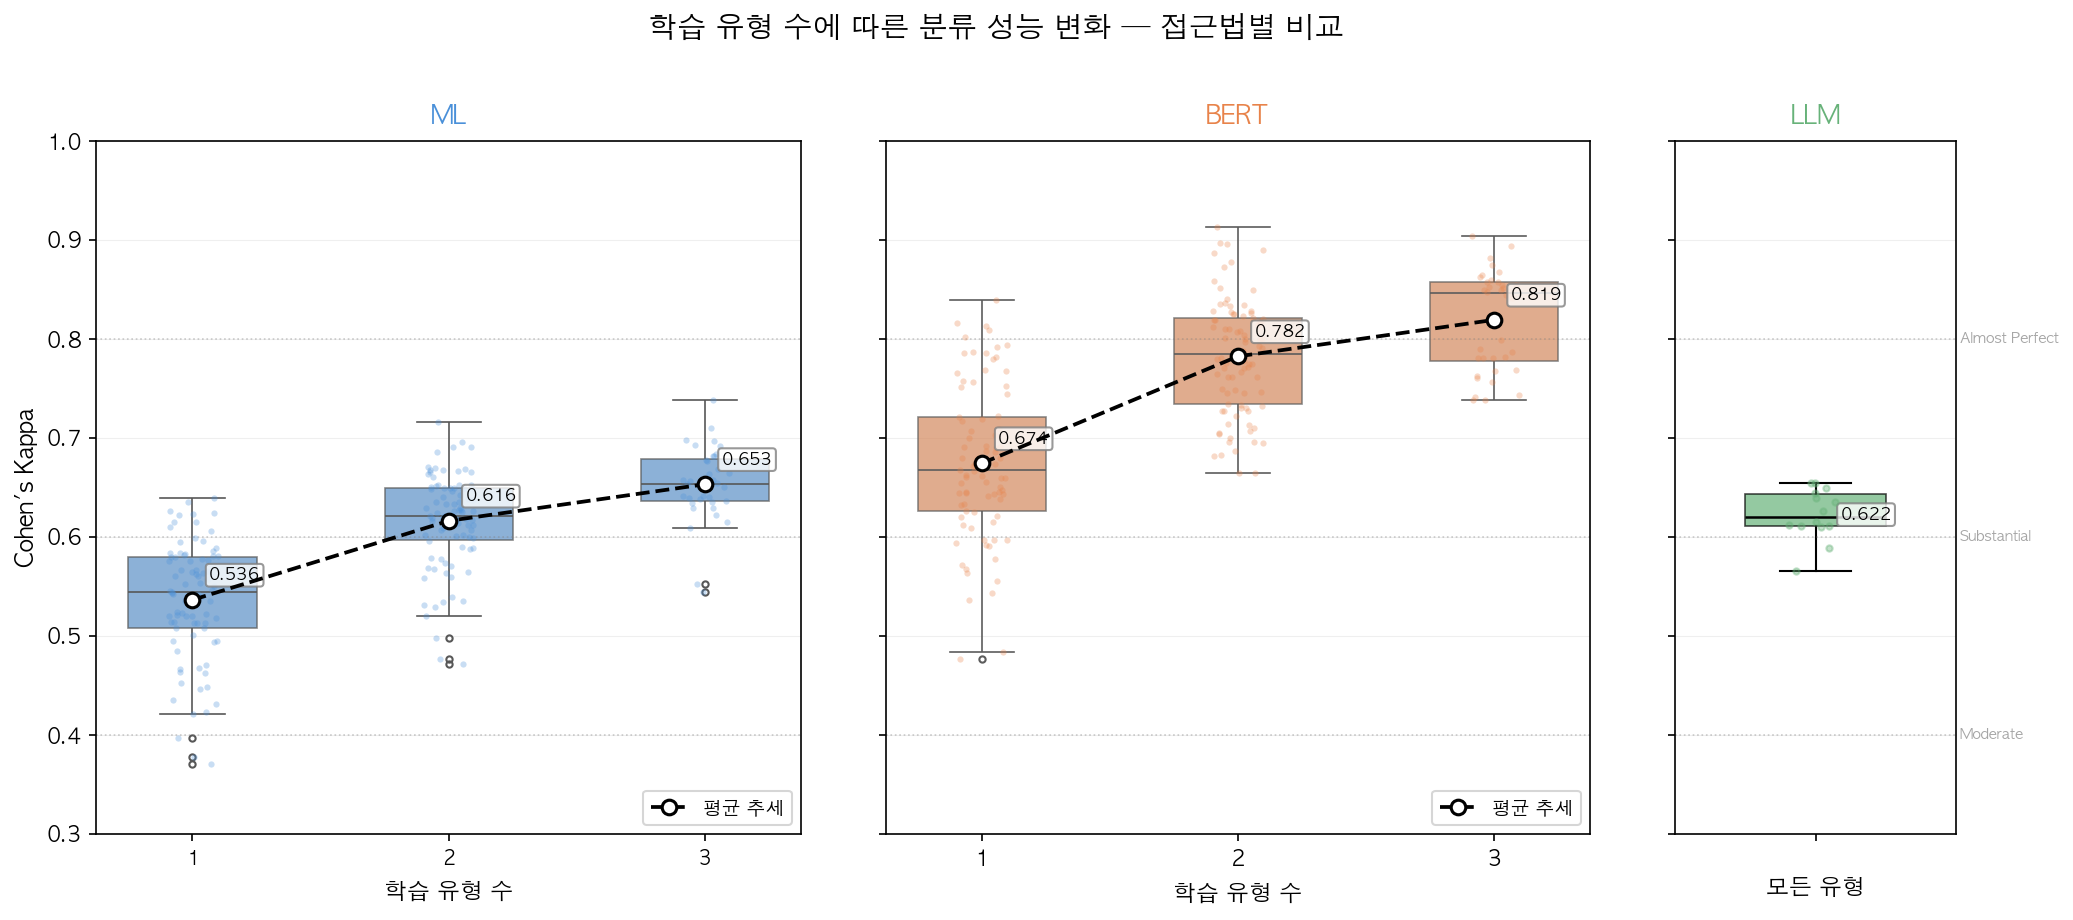

LLM 고유 Kappa 값: 14개, 평균=0.6225
ML 추세:  0.536 → 0.616 → 0.653
BERT 추세: 0.674 → 0.782 → 0.819


In [23]:
# ============================================================
# D) 접근법별 개별 박스플롯 + 평균 추세선
# - ML, BERT: x축 = 1유형/2유형/3유형 (박스플롯 + 추세선)
# - LLM: x축 = '모든 유형' 1개로 통합 (학습 효과 없으므로)
# ============================================================

fig = plt.figure(figsize=(16, 6))

# 서브플롯 비율: ML과 BERT는 넓게, LLM은 좁게
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 1.2], wspace=0.15)
ax_ml   = fig.add_subplot(gs[0])
ax_bert = fig.add_subplot(gs[1], sharey=ax_ml)
ax_llm  = fig.add_subplot(gs[2], sharey=ax_ml)

# 유형 수별 데이터 포인트 수
type_counts = type_combo.groupby('n_train_types').size()
x_labels_3 = [f'{t}' for t in [1, 2, 3]]

# ---- ML ----
ml_data = df_long[df_long['Approach'] == 'ML']
sns.boxplot(data=ml_data, x='n_train_types', y='Kappa',
            color=PALETTE['ML'], ax=ax_ml, width=0.5, fliersize=3,
            linewidth=0.8, boxprops=dict(alpha=0.7))
sns.stripplot(data=ml_data, x='n_train_types', y='Kappa',
              color=PALETTE['ML'], ax=ax_ml, size=3, alpha=0.3, jitter=True)

ml_means = ml_data.groupby('n_train_types')['Kappa'].mean().sort_index()
ax_ml.plot(range(3), ml_means.values, 'k--o', markersize=7, linewidth=1.8,
           markerfacecolor='white', markeredgecolor='black',
           markeredgewidth=1.5, zorder=10, label='평균 추세')
for xp, mv in zip(range(3), ml_means.values):
    ax_ml.annotate(f'{mv:.3f}', xy=(xp, mv), xytext=(8, 8),
                   textcoords='offset points', fontsize=8, fontweight='bold',
                   ha='left', va='bottom',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                             edgecolor='gray', alpha=0.8))
ax_ml.set_title('ML', fontsize=12, fontweight='bold',
                pad=8, color=PALETTE['ML'])
ax_ml.set_xlabel('학습 유형 수', fontsize=11, fontweight='bold', labelpad=6)
ax_ml.set_ylabel("Cohen's Kappa", fontsize=11, fontweight='bold')
ax_ml.set_xticklabels(x_labels_3, fontsize=9)
ax_ml.legend(fontsize=9, loc='lower right')

# ---- BERT ----
bert_data = df_long[df_long['Approach'] == 'BERT']
sns.boxplot(data=bert_data, x='n_train_types', y='Kappa',
            color=PALETTE['BERT'], ax=ax_bert, width=0.5, fliersize=3,
            linewidth=0.8, boxprops=dict(alpha=0.7))
sns.stripplot(data=bert_data, x='n_train_types', y='Kappa',
              color=PALETTE['BERT'], ax=ax_bert, size=3, alpha=0.3, jitter=True)

bert_means = bert_data.groupby('n_train_types')['Kappa'].mean().sort_index()
ax_bert.plot(range(3), bert_means.values, 'k--o', markersize=7, linewidth=1.8,
             markerfacecolor='white', markeredgecolor='black',
             markeredgewidth=1.5, zorder=10, label='평균 추세')
for xp, mv in zip(range(3), bert_means.values):
    ax_bert.annotate(f'{mv:.3f}', xy=(xp, mv), xytext=(8, 8),
                     textcoords='offset points', fontsize=8, fontweight='bold',
                     ha='left', va='bottom',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                               edgecolor='gray', alpha=0.8))
ax_bert.set_title('BERT', fontsize=12, fontweight='bold',
                  pad=8, color=PALETTE['BERT'])
ax_bert.set_xlabel('학습 유형 수', fontsize=11, fontweight='bold', labelpad=6)
ax_bert.set_ylabel('')
plt.setp(ax_bert.get_yticklabels(), visible=False)
ax_bert.legend(fontsize=9, loc='lower right')

# ---- LLM (모든 유형 통합) ----
llm_data = df_long[df_long['Approach'] == 'LLM']
# 고유 kappa만 사용 (중복 제거)
llm_unique = llm_data.drop_duplicates(subset='Kappa')

ax_llm.boxplot(
    llm_unique['Kappa'].values,
    positions=[0], widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE['LLM'], alpha=0.7, linewidth=0.8),
    medianprops=dict(color='black', linewidth=1.2),
    flierprops=dict(markersize=3),
)
# 개별 데이터 포인트
ax_llm.scatter(
    np.zeros(len(llm_unique)) + np.random.normal(0, 0.04, len(llm_unique)),
    llm_unique['Kappa'].values,
    color=PALETTE['LLM'], s=9, alpha=0.4, zorder=5,
)
# 평균값 표시
llm_mean = llm_unique['Kappa'].mean()
ax_llm.annotate(
    f'{llm_mean:.3f}', xy=(0, llm_mean), xytext=(12, 0),
    textcoords='offset points', fontsize=8, fontweight='bold',
    ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
              edgecolor='gray', alpha=0.8),
)

ax_llm.set_title('LLM', fontsize=12, fontweight='bold',
                 pad=8, color=PALETTE['LLM'])
ax_llm.set_xlabel('모든 유형', fontsize=11)  # 높이 맞춤용
ax_llm.set_xticks([0])
ax_llm.set_xticklabels([f' '], fontsize=9)
ax_llm.set_ylabel('')
plt.setp(ax_llm.get_yticklabels(), visible=False)

# ---- 공통: y축 범위, 기준선, 그리드 ----
for ax in [ax_ml, ax_bert, ax_llm]:
    ax.set_ylim(0.3, 1.0)
    for y_val in [0.4, 0.6, 0.8]:
        ax.axhline(y=y_val, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

# ---- 기준선 라벨: fig.text()로 1회만 표시 ----
# tight_layout 이후 좌표 확정을 위해 먼저 레이아웃 적용
fig.suptitle('학습 유형 수에 따른 분류 성능 변화 — 접근법별 비교',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.canvas.draw()

for y_val, y_label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
    # LLM 축의 data 좌표 → figure 좌표로 변환
    disp = ax_llm.transData.transform((0, y_val))
    fig_coord = fig.transFigure.inverted().transform(disp)
    fig.text(fig_coord[0] + 0.06, fig_coord[1], y_label,
             fontsize=7, color='gray', alpha=0.7, va='center', ha='left')

plt.savefig('type_boxplot_D_by_approach.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- 요약 ---
print(f'LLM 고유 Kappa 값: {len(llm_unique)}개, 평균={llm_mean:.4f}')
print(f'ML 추세:  {" → ".join(f"{v:.3f}" for v in ml_means.values)}')
print(f'BERT 추세: {" → ".join(f"{v:.3f}" for v in bert_means.values)}')